# 🏆 Pronostics CDM 2026 — Phase de groupes (analyse explorable)

Notebook d'analyse des pronostics de scores des **72 matchs de phase de groupes**
de la Coupe du Monde 2026 (48 équipes, 12 groupes).

**Méthodologie hybride :**
1. **Modèle quantitatif** — un modèle de **Poisson** dont les buts attendus dérivent
   des notes **Elo** des équipes (+ avantage hôte) → score de base + probabilités V/N/D.
2. **Couche multi-agents** — 12 agents *prédicteurs* (recherche forme/effectif/blessures)
   ajustent le baseline, puis 4 agents *critiques* challengent réalisme et cohérence.
3. **Synthèse** — `data/predictions.csv` (scores finaux), classements et qualifiés calculés ici.

> ⏱️ Contexte : le tournoi a débuté le 11/06/2026. **J1 = résultats réels** (groupes A–H),
> **J2/J3 = pronostics**. Les groupes I–L n'avaient pas encore joué au 16/06/2026.

Ce notebook est **rejouable** : modifiez les paramètres du modèle et tout se recalcule.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Se placer à la racine du dépôt (le notebook vit dans notebooks/)
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import model_pronos as mp
import standings as S

pd.set_option("display.max_rows", 100)
plt.rcParams["figure.figsize"] = (9, 4)
print("Dossier de travail :", os.getcwd())

Dossier de travail : /home/user/mpp-pronos


## 1. Données : groupes, notes de force, calendrier

In [2]:
import json
groupes = json.load(open("data/groups.json"))["groupes"]
ratings = pd.read_csv("data/team_ratings.csv")
fixtures = pd.read_csv("data/fixtures.csv")
predictions = pd.read_csv("data/predictions.csv")

print(f"{len(ratings)} équipes, {len(fixtures)} matchs, {len(predictions)} pronostics.")
ratings.sort_values("elo", ascending=False).head(12)

48 équipes, 72 matchs, 72 pronostics.


,groupe,equipe,pot,hote,elo,fifa_rank,forme_note
28,H,Espagne,1,non,2171,2,Championne d'Europe 2024; n°1 Elo; effectif ex...
36,J,Argentine,1,non,2113,1,Championne du monde en titre; n°1 FIFA; Messi ...
32,I,France,1,non,2063,3,Finaliste Ligue des Nations; effectif ultra-pr...
44,L,Angleterre,1,non,2042,4,Finaliste Euro 2024; qualif parfaite sous Tuch...
41,K,Colombie,2,non,1998,13,Excellente Elo; finaliste Copa América 2024; J...
8,C,Brésil,1,non,1991,6,Sous Ancelotti; fin de qualif CONMEBOL solide;...
20,F,Pays-Bas,1,non,1976,7,1er de son groupe qualif; attaque forte sous K...
40,K,Portugal,1,non,1976,5,Génération dorée (Ronaldo en fin); qualif soli...
16,E,Allemagne,1,non,1934,10,3e Ligue des Nations 2025; 1er de son groupe q...
45,L,Croatie,2,non,1933,11,Génération Modric en fin; toujours redoutable ...


### Notes de force (Elo) par groupe

L'Elo est le moteur du modèle. Les valeurs proviennent de eloratings.net / classement FIFA
(juin 2026), complétées par les agents de recherche. Voir `data/team_ratings.csv` pour les sources.

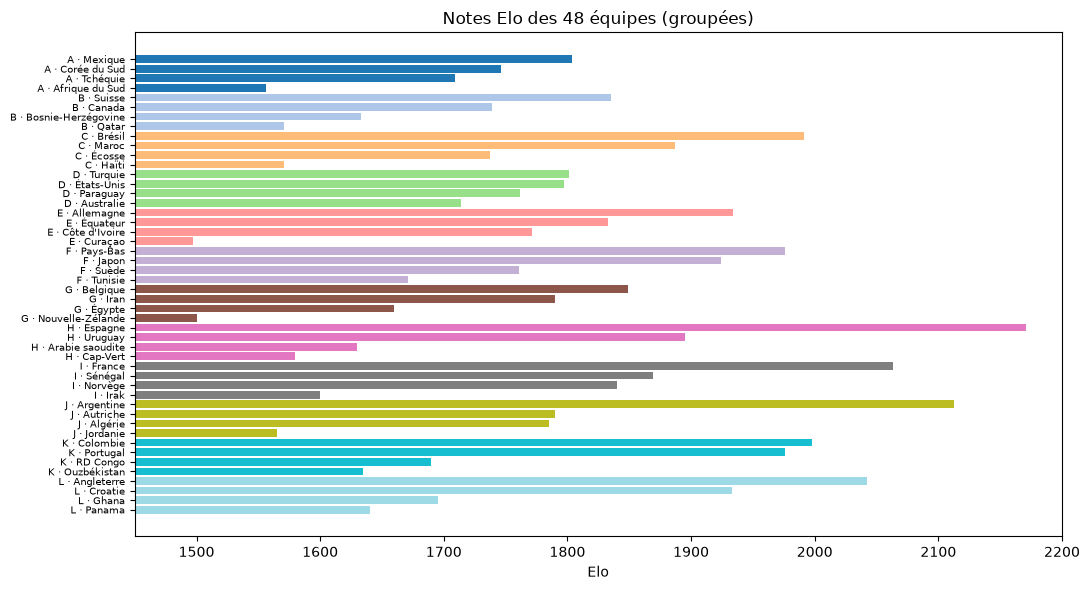

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))
order = ratings.sort_values(["groupe", "elo"], ascending=[True, False])
colors = plt.cm.tab20(np.linspace(0, 1, 12))
gmap = {g: colors[i] for i, g in enumerate(sorted(ratings.groupe.unique()))}
ax.barh(range(len(order)), order.elo, color=[gmap[g] for g in order.groupe])
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"{r.groupe} · {r.equipe}" for _, r in order.iterrows()], fontsize=7)
ax.invert_yaxis(); ax.set_xlabel("Elo"); ax.set_xlim(1450, 2200)
ax.set_title("Notes Elo des 48 équipes (groupées)")
plt.tight_layout(); plt.show()

## 2. Le modèle de Poisson (cœur quantitatif)

Pour un match, on calcule les buts attendus de chaque équipe :

- différence Elo effective `dr = elo_dom - elo_ext (+ avantage hôte)`
- **supremacy** (différence de buts attendue) : `sup = 3.6 · tanh(dr / 350)` (bornée)
- **buts totaux** attendus : `TG = 2.5 + 0.35 · |sup|` (croît avec le déséquilibre)
- `λ_dom = (TG + sup)/2`, `λ_ext = (TG - sup)/2`

Puis on suppose deux lois de **Poisson indépendantes** pour obtenir la matrice des scores,
le score le plus probable et les probabilités Victoire / Nul / Défaite.

Les paramètres sont dans `model_pronos.py` — modifiez-les et réexécutez pour explorer la sensibilité.

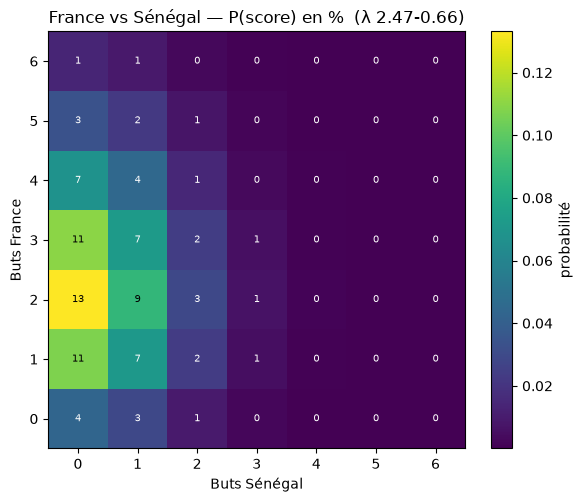

{'xg_dom': 2.47, 'xg_ext': 0.66, 'score_modele': '2-0', 'buts_dom_modele': 2, 'buts_ext_modele': 0, 'p_victoire_dom': 0.771, 'p_nul': 0.15, 'p_victoire_ext': 0.079}


In [4]:
# Exemple : matrice des scores d'un match
elo = dict(zip(ratings.equipe, ratings.elo))
dom, ext = "France", "Sénégal"
lam_d, lam_e = mp.lambdas(elo[dom], elo[ext], dom, ext)
M = mp.matrice_scores(lam_d, lam_e, n=6)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(M, cmap="viridis", origin="lower")
for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{M[i,j]*100:.0f}", ha="center", va="center",
                color="white" if M[i,j] < M.max()*0.6 else "black", fontsize=7)
ax.set_xlabel(f"Buts {ext}"); ax.set_ylabel(f"Buts {dom}")
ax.set_title(f"{dom} vs {ext} — P(score) en %  (λ {lam_d:.2f}-{lam_e:.2f})")
plt.colorbar(im, label="probabilité"); plt.tight_layout(); plt.show()
print(mp.pronostic(elo[dom], elo[ext], dom, ext))

## 3. Validation : le modèle face aux résultats réels de la J1

Le modèle « avant-match » (qui ne connaît que l'Elo) a-t-il bien anticipé la J1 déjà jouée ?
On compare le **baseline Poisson** aux **scores réels** (groupes A–H).

In [5]:
base = pd.read_csv("data/predictions_baseline.csv")
joues = fixtures[fixtures.statut == "joue"].copy()
bcols = ["groupe", "journee", "equipe_dom", "equipe_ext",
         "score_modele", "buts_dom_modele", "buts_ext_modele"]
val = joues.merge(base[bcols], on=["groupe", "journee", "equipe_dom", "equipe_ext"])
def issue(a, b):
    return "V" if a > b else ("D" if a < b else "N")
rows = []
for _, r in val.iterrows():
    ra, rb = map(int, str(r.score_reel).split("-"))
    rows.append({
        "match": f"{r.equipe_dom}-{r.equipe_ext}", "réel": r.score_reel,
        "modèle": r.score_modele,
        "issue_ok": issue(ra, rb) == issue(r.buts_dom_modele, r.buts_ext_modele),
    })
vdf = pd.DataFrame(rows)
taux = vdf.issue_ok.mean()
print(f"Issue (V/N/D) correctement prédite par le modèle : {vdf.issue_ok.sum()}/{len(vdf)} = {taux:.0%}")
vdf

Issue (V/N/D) correctement prédite par le modèle : 6/16 = 38%


,match,réel,modèle,issue_ok
0,Mexique-Afrique du Sud,2-0,2-0,True
1,Corée du Sud-Tchéquie,2-1,1-1,False
2,Canada-Bosnie-Herzégovine,1-1,2-0,False
3,Qatar-Suisse,1-1,0-2,False
4,Brésil-Maroc,1-1,1-0,False
5,Haïti-Écosse,0-1,0-2,True
6,États-Unis-Paraguay,4-1,1-0,True
7,Australie-Turquie,2-0,0-1,False
8,Allemagne-Curaçao,7-1,3-0,True
9,Côte d'Ivoire-Équateur,1-0,1-1,False


La J1 a livré plusieurs **surprises** (Espagne 0-0 Cap-Vert, Belgique 1-1 Égypte,
Iran 2-2 Nouvelle-Zélande…) que le modèle Elo pur ne pouvait pas anticiper — d'où l'intérêt
de la couche d'experts. C'est le rappel classique que le football reste imprévisible à court terme.

## 4. Pronostics finaux des 72 matchs

In [6]:
def fmt(r):
    tag = "✅ réel" if r.statut == "joue" else "🔮 prono"
    return f"J{r.journee}  {r.equipe_dom} {r.buts_dom}-{r.buts_ext} {r.equipe_ext}   [{tag}]  P(V/N/D)={r.p_victoire_dom:.2f}/{r.p_nul:.2f}/{r.p_victoire_ext:.2f}"
for g in sorted(predictions.groupe.unique()):
    print(f"=== Groupe {g} ===")
    for _, r in predictions[predictions.groupe == g].iterrows():
        print("  " + fmt(r))
    print()

=== Groupe A ===
  J1  Mexique 2-0 Afrique du Sud   [✅ réel]  P(V/N/D)=0.86/0.10/0.04
  J1  Corée du Sud 2-1 Tchéquie   [✅ réel]  P(V/N/D)=0.48/0.25/0.27
  J2  Tchéquie 1-0 Afrique du Sud   [🔮 prono]  P(V/N/D)=0.58/0.27/0.15
  J2  Mexique 1-1 Corée du Sud   [🔮 prono]  P(V/N/D)=0.40/0.30/0.30
  J3  Tchéquie 1-1 Mexique   [🔮 prono]  P(V/N/D)=0.24/0.31/0.45
  J3  Afrique du Sud 0-2 Corée du Sud   [🔮 prono]  P(V/N/D)=0.12/0.22/0.66

=== Groupe B ===
  J1  Canada 1-1 Bosnie-Herzégovine   [✅ réel]  P(V/N/D)=0.30/0.40/0.30
  J1  Qatar 1-1 Suisse   [✅ réel]  P(V/N/D)=0.18/0.40/0.42
  J2  Suisse 2-0 Bosnie-Herzégovine   [🔮 prono]  P(V/N/D)=0.74/0.16/0.10
  J2  Canada 2-0 Qatar   [🔮 prono]  P(V/N/D)=0.78/0.15/0.07
  J3  Suisse 2-1 Canada   [🔮 prono]  P(V/N/D)=0.50/0.27/0.23
  J3  Bosnie-Herzégovine 2-1 Qatar   [🔮 prono]  P(V/N/D)=0.50/0.26/0.24

=== Groupe C ===
  J1  Brésil 1-1 Maroc   [✅ réel]  P(V/N/D)=0.40/0.32/0.28
  J1  Haïti 0-1 Écosse   [✅ réel]  P(V/N/D)=0.12/0.22/0.66
  J2  Écosse 1-2 

## 5. Classements de groupe (départages FIFA)

In [7]:
classements = S.tous_classements(predictions)
for g in sorted(classements):
    print(f"=== Groupe {g} ===")
    print(classements[g].to_string())
    print()

=== Groupe A ===
              equipe  J  G  N  P  bp  bc  diff  pts
rang                                               
1       Corée du Sud  3  2  1  0   5   2     3    7
2            Mexique  3  1  2  0   4   2     2    5
3           Tchéquie  3  1  1  1   3   3     0    4
4     Afrique du Sud  3  0  0  3   0   5    -5    0

=== Groupe B ===
                  equipe  J  G  N  P  bp  bc  diff  pts
rang                                                   
1                 Suisse  3  2  1  0   5   2     3    7
2                 Canada  3  1  1  1   4   3     1    4
3     Bosnie-Herzégovine  3  1  1  1   3   4    -1    4
4                  Qatar  3  0  1  2   2   5    -3    1

=== Groupe C ===
      equipe  J  G  N  P  bp  bc  diff  pts
rang                                       
1     Brésil  3  2  1  0   6   1     5    7
2      Maroc  3  2  1  0   5   2     3    7
3     Écosse  3  1  0  2   2   4    -2    3
4      Haïti  3  0  0  3   0   6    -6    0

=== Groupe D ===
          equipe 

## 6. Qualifiés pour les 1/16 de finale

Format 2026 : **32 qualifiés** = 12 premiers + 12 deuxièmes + **8 meilleurs troisièmes**.

In [8]:
premiers, deuxiemes, meilleurs3, df3 = S.qualifies(classements)
print("MEILLEURS 3es (classés) — les 8 premiers sont qualifiés :")
df3_aff = df3.copy(); df3_aff["qualifié"] = ["✅"]*8 + ["❌"]*(len(df3)-8)
print(df3_aff.to_string(index=False))

MEILLEURS 3es (classés) — les 8 premiers sont qualifiés :
groupe             equipe  pts  diff  bp qualifié
     F              Japon    4     1   5        ✅
     E           Équateur    4     1   3        ✅
     J            Algérie    4     0   3        ✅
     I            Norvège    4     0   3        ✅
     A           Tchéquie    4     0   3        ✅
     B Bosnie-Herzégovine    4    -1   3        ✅
     D            Turquie    4    -1   3        ✅
     K           RD Congo    3    -2   3        ✅
     C             Écosse    3    -2   2        ❌
     G               Iran    2    -1   4        ❌
     H           Cap-Vert    2    -1   1        ❌
     L              Ghana    1    -3   2        ❌


In [9]:
tab = pd.DataFrame({
    "1ers (groupe gagné)": [f"{g}: {e}" for g, e in premiers],
    "2es": [f"{g}: {e}" for g, e in deuxiemes],
})
m3 = meilleurs3.reset_index(drop=True)
tab["meilleurs 3es"] = [f"{r.groupe}: {r.equipe}" for _, r in m3.iterrows()] + [""]*(12-len(m3))
tab.index = [f"#{i+1}" for i in range(12)]
print("LES 32 QUALIFIÉS"); tab

LES 32 QUALIFIÉS


,1ers (groupe gagné),2es,meilleurs 3es
#1,A: Corée du Sud,A: Mexique,F: Japon
#2,B: Suisse,B: Canada,E: Équateur
#3,C: Brésil,C: Maroc,J: Algérie
#4,D: États-Unis,D: Australie,I: Norvège
#5,E: Allemagne,E: Côte d'Ivoire,A: Tchéquie
#6,F: Suède,F: Pays-Bas,B: Bosnie-Herzégovine
#7,G: Belgique,G: Égypte,D: Turquie
#8,H: Espagne,H: Uruguay,K: RD Congo
#9,I: France,I: Sénégal,
#10,J: Argentine,J: Autriche,


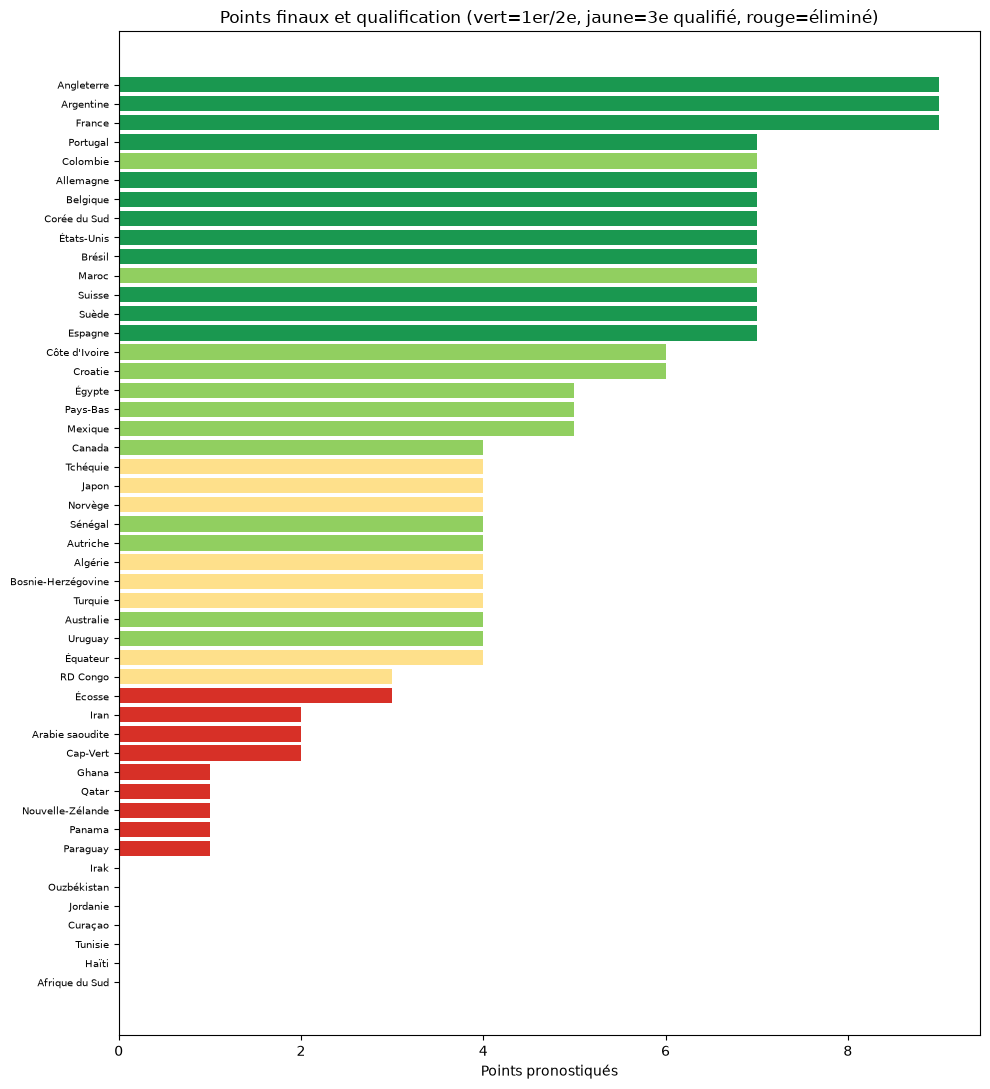

In [10]:
# Visualisation : points finaux, 1ers / 2es / 3es qualifiés / éliminés
q1 = {e for _, e in premiers}; q2 = {e for _, e in deuxiemes}
q3 = set(meilleurs3.equipe)
def statut(eq):
    if eq in q1: return ("1er", "#1a9850")
    if eq in q2: return ("2e", "#91cf60")
    if eq in q3: return ("3e qualifié", "#fee08b")
    return ("éliminé", "#d73027")
allt = pd.concat(classements.values())
allt = allt.sort_values("pts")
labels, vals, cols = [], [], []
for _, r in allt.iterrows():
    s, c = statut(r.equipe); labels.append(r.equipe); vals.append(r.pts); cols.append(c)
fig, ax = plt.subplots(figsize=(10, 11))
ax.barh(range(len(labels)), vals, color=cols)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("Points pronostiqués"); ax.set_title("Points finaux et qualification (vert=1er/2e, jaune=3e qualifié, rouge=éliminé)")
plt.tight_layout(); plt.show()

## 7. Pour aller plus loin

- Modifiez un Elo dans `data/team_ratings.csv` ou un paramètre dans `model_pronos.py`,
  réexécutez `build_predictions.py` puis ce notebook pour voir l'impact.
- Le départage des **meilleurs 3es** est extrêmement serré (plusieurs équipes à 4 pts) :
  un seul but change un qualifié. C'est le principal facteur d'incertitude des pronostics.
- Hors périmètre ici : la phase à élimination directe (1/16 et au-delà).